# Simulated Data
- The perpetual problem with this project is the lack of good data :<
- Can try mitigate this with some simulated data.
---
- Start with a distribution of star types. 
- Draw a star type from this distribution.
- Draw Prot and Pcyc from distributions defined in SM2016.
- Draw Plong between 50 and 150 years randomly.
- From solar data {https://link.springer.com/article/10.12942/lrsp-2010-1}, the sunspot count varies by roughly 2 times from peak to peak. Plong envelope can then be stochastic about this.
- The amplitudes are a matter of scientific uncertainty.
    - SM2016 Fig 19 implies shorter rotation periods go with larger cycle amplitudes.
    - This contradicts Saar and Brandenburg 2002.
    - May just be easier to draw from a KDE of Fig 22 in SM2016.
- Noise is difficult to do. Just use same error_percent on each point as the magnitude of a Gaussian spread.


In [1]:
import numpy as np

### Star type dist
- We only have data for FGKM stars.
- {https://ui.adsabs.harvard.edu/abs/2001JRASC..95...32L/abstract} has the probabilities of each.
    - F: 3
    - G: 7.6
    - K: 12
    - M: 76 {https://iopscience.iop.org/article/10.3847/1538-4365/abd7a8}
        - Early M: 95 thereof
        - Mid M: 5 thereof

In [2]:
probs_unscaled = [0.03, 0.076, 0.12, 0.76*0.95, 0.76*0.05]
labels = np.array(["F", "G", "K", "ME", "MM"])
probs = probs_unscaled/np.sum(probs_unscaled)
star_type = np.random.choice(len(probs), p=probs, size=100)

In [3]:
from scipy.stats import truncnorm

P_cyc_lookup = np.array([[9.5, 5.3],[6.7,3.6],[8.5,3.6],[6.0,2.9],[7.1,2.7]]) # FGKMEMM, Years, mu sigma
P_rot_lookup = np.array([[8.6, 6.2],[19.6,11.1],[27.4,15.7],[36.2,29.9],[85.4,53.4]]) # Days

P_cyc_samp = P_cyc_lookup[star_type]
P_rot_samp = P_rot_lookup[star_type]

# Use truncated normal to not have negative periods
a_cyc = -P_cyc_samp[:,0]/ P_cyc_samp[:,1]  # lower bound in standardised units
a_rot = -P_rot_samp[:,0]/ P_rot_samp[:,1] 

P_cycs = truncnorm.rvs(a_cyc, np.inf, loc=P_cyc_samp[:,0], scale=P_cyc_samp[:,1])
P_rots = truncnorm.rvs(a_rot, np.inf, loc=P_rot_samp[:,0], scale=P_rot_samp[:,1])

# Draw P_long from 50 to 150
P_longs =  np.random.default_rng().uniform(low=50,high=150,size=100)

- Now draw the amplitudes.

In [ ]:
A_longs = np.random.default_rng().uniform(low=1,high=3,size=100) # 1 means no osc 3 means max peak is 3x smallest peak

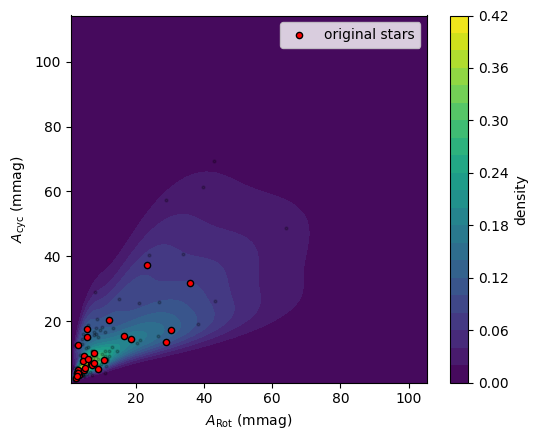

In [24]:
# SM2016 Fig 22 KDE to get A_cyc and A_rot
import pandas as pd
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

df = pd.read_csv("../../Data/table_A2_full.csv")
both_df = df.dropna(subset=["Acycle_mmag", "Arot_mmag"]) # Which ones have both

# KDE in logspace to enforce positvity and to help with the range
log_arot = np.log(both_df['Arot_mmag'])
log_acyc = np.log(both_df['Acycle_mmag'])

kde_data = np.vstack([log_arot, log_acyc])
kde = gaussian_kde(kde_data)

# sample in log-space,
log_samples = kde.resample(100, seed=1701)
log_arot_samp = log_samples[0]
log_acyc_samp = log_samples[1]
A_rots = np.exp(log_arot_samp)
A_cycs = np.exp(log_acyc_samp)


# build the grid IN LOG SPACE (matches what the KDE was fit on)
log_xgrid = np.linspace(log_arot_samp.min() - 0.5, log_arot_samp.max() + 0.5, 200)
log_ygrid = np.linspace(log_acyc_samp.min() - 0.5, log_acyc_samp.max() + 0.5, 200)
LogXg, LogYg = np.meshgrid(log_xgrid, log_ygrid)

positions = np.vstack([LogXg.ravel(), LogYg.ravel()])
Z = kde(positions).reshape(LogXg.shape)

# exponentiate the GRID AXES (not the density Z) to plot in linear mmag
Xg = np.exp(LogXg)
Yg = np.exp(LogYg)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
cf = ax.contourf(Xg, Yg, Z, levels=20, cmap="viridis")
ax.scatter(A_rots, A_cycs, s=4, alpha=0.2, color='black')
ax.scatter(both_df['Arot_mmag'], both_df['Acycle_mmag'],
           s=20, color="red", edgecolor="black", zorder=3, label="original stars")
ax.set_xlabel(r"$A_{\rm Rot}$ (mmag)")
ax.set_ylabel(r"$A_{\rm cyc}$ (mmag)")
ax.legend()
fig.colorbar(cf, label="density")
fig.tight_layout()

- Now we need to define the things